# STARE-PODS — Rendezvous Analytics

*Companion notebook for the video walkthrough. Everything runs live against
**AWS S3** (Parquet chunks) + **RDS Postgres** (the `PodsMetadata` catalog);
the granules were ingested beforehand, so this notebook only queries.*

**STARE-PODS** — the **STARE Parallel Optimized Data Store** — leverages the
STARE quad-tree hierarchy to partition and organize geospatial data, and thus
enables distributed parallel processing of native data without requiring
re-gridding, i.e. resampling and/or re-projection.

For this demo of the STARE-PODS prototype, swaths of level 1C data from four
microwave radiometers — GPM's **GMI**, DMSP's **SSMIS**, GCOM-W1's **AMSR2**,
and JPSS's **ATMS** — were decomposed at quad-furcation level four (**QL4**).
This results in 2048 pods, corresponding to 2048 QL4 STARE spherical
triangles, or *trixels*, each ~600+ km on a side, or an area of approximately
200,000 km². The decomposition extracts the data elements of each swath that
overlap a given QL4 trixel and packages them into a Parquet chunk file —
so a pod (a logical construct) contains data chunks from **all** the swaths
that overlap (non-empty intersect) with the pod area: a natural spatial
co-location.

During the decomposition, a database management system (PostgreSQL)
catalogues all necessary information to reconstitute the swath granule — the
chunk's granule and pod identities, its space-time extents, etc., as well as
the metadata of the original HDF/netCDF file. Because the database holds the
chunks' spatiotemporal information, it can serve as a cross-instrument
**rendezvous engine**.

The store holds the **first quarter of 2025** — every Level 1C granule of
the four instruments from January 1 to March 31, about 7,400 granules
decomposed into 12.5 million chunks. The statistics — Parts 1, 2 and 6 —
run on the whole quarter. Parts 3, 4 and 5 zoom in on **six** of those
granules from one day (2025-01-01) so every figure stays legible, and
Part 5.1 repeats Part 5's query against the whole store.

1. **The temporal catalog** — every chunk knows *where* and *when* (the quarter)
2. **Rendezvous analytics** — who met whom, over the whole quarter
3. **Maps of rendezvous in swaths** — the coverage map (six granules)
4. **Rendezvous up close** — the tightest pair, then all four (six granules)
5. **Rendezvous over a region of interest** — space and time in one query (six granules)
   - 5.1 — the same region query against the whole store
6. **Performance at scale** — the whole quarter, timed at four scopes


In [1]:
import time
_setup_t0 = time.perf_counter()          # so this setup cell is timed too
from IPython import get_ipython

# Per-cell timing: every later cell self-reports "⏱ cell [n] took X.XXs" and
# the summary cell at the end totals them. Registered by name so re-running
# this cell cannot stack duplicate hooks.
CELL_TIMINGS = {}
_cell_start = {}


def _time_pre(info):
    _cell_start['t0'] = time.perf_counter()


def _time_post(result):
    t0 = _cell_start.pop('t0', None)
    if t0 is None:                       # cell failed before pre_run_cell ran
        return
    elapsed = time.perf_counter() - t0
    CELL_TIMINGS[result.execution_count] = elapsed
    print(f"\u23f1  cell [{result.execution_count}] took {elapsed:.2f}s")


_ip = get_ipython()
for _event, _fn in (('pre_run_cell', _time_pre), ('post_run_cell', _time_post)):
    for _old in [f for f in _ip.events.callbacks[_event] if f.__name__ == _fn.__name__]:
        _ip.events.unregister(_event, _old)
    _ip.events.register(_event, _fn)
_cell_start['t0'] = _setup_t0

import logging
import re
import os
from contextlib import contextmanager
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from great_tables import loc, style
from great_tables import GT as _GT


def GT(frame, **kwargs):
    """great_tables.GT, house-styled: bold centered title, centered subtitle
    (inline styles, so the notebook viewer's own table CSS cannot override
    them), and plain-word column labels auto-capitalized — code identifiers
    such as t_start keep their spelling."""
    table = (_GT(frame, **kwargs)
             .tab_style(style=style.text(align='center', weight='bold'),
                        locations=loc.title())
             .tab_style(style=style.text(align='center'),
                        locations=loc.subtitle()))
    labels = {c: c[0].upper() + c[1:] for c in frame.columns
              if isinstance(c, str) and re.fullmatch(r'[a-z][a-z ]*', c)}
    if labels:
        table = table.cols_label(labels)
    return table

logging.getLogger('starepandas').setLevel(logging.WARNING)  # keep outputs clean

import starepandas
from starepandas.demo_lib import StarePodsDemo
from starepandas.staredataframe import parse_chunk_filename, sid_to_podcode
from starepandas.io.granules import (
    load_s3_catalog_summary, load_s3_metadata, load_s3_pod_occupancy,
    load_s3_temporal_catalog,
)
from starepandas.overlap import (
    rendezvous_events, overlap_matrix, overlap_pod_table, pod_drilldown,
    fold_instrument,
)
from starepandas.demo_plots import (
    chunk_pixels, plot_pod_coverage, plot_region_cover, plot_region_result,
    plot_rendezvous, pod_pixels, pod_trixels, rendezvous_examples,
)

CONFIG_PATH = os.path.join(
    os.path.dirname(os.path.abspath(starepandas.__file__)), ".config")
S3_PREFIX = "s3://zarrpods/gmi-demo-parquet"    # the six-granule walkthrough root (Parts 2-5)
STORE_PREFIX = "s3://zarrpods/storage"          # the Q1-2025 bulk-store root (Parts 1 and 6)
ROOTS = {                                       # the three disjoint storage roots of the quarter
    STORE_PREFIX: "Q1 2025 bulk ingest (cloud workers)",
    S3_PREFIX: "six-granule walkthrough (Parts 2-5)",
    "s3://zarrpods/testing-s3/loadtest-jan/storage": "load test (10 SSMIS granules)",
}
OVERLAP_DT = pd.Timedelta(minutes=45)           # coincidence window Δt
STARE_LEVEL = 4
INSTRUMENTS = ["GMI", "SSMIS", "AMSR2", "ATMS"]


class StepTimer:
    """Sub-step stopwatch for one cell: ``with T.step(kind, what): ...``
    records wall-clock seconds per step, tagged by kind — ``query`` (the
    database or S3 listing answers), ``download`` (chunk bytes from S3),
    ``local`` (pandas / STARE work on this computer), ``plot`` (building a
    matplotlib figure) and ``display`` (rendering a table or figure into the
    notebook). ``T.table()`` shows the breakdown with per-kind totals."""

    def __init__(self):
        self.steps = []
        self.last = None

    @contextmanager
    def step(self, kind, what):
        t0 = time.perf_counter()
        yield
        self.last = time.perf_counter() - t0
        self.steps.append({'kind': kind, 'step': what, 'seconds': self.last})

    def frame(self):
        df = pd.DataFrame(self.steps)
        df['share'] = df['seconds'] / df['seconds'].sum()
        return df

    def table(self, title):
        df = self.frame()
        by_kind = df.groupby('kind', sort=False)['seconds'].sum()
        note = ' · '.join(f"{k}: {v:.1f} s" for k, v in by_kind.items())
        return (GT(df)
                .tab_header(title=title,
                            subtitle=f"{df['seconds'].sum():.1f} s over "
                                     f"{len(df)} steps, in the order they ran")
                .fmt_number(columns='seconds', decimals=2)
                .fmt_percent(columns='share', decimals=0)
                .cols_label(kind="", step="", seconds="Seconds", share="Share")
                .tab_source_note(f"by kind — {note}"))


def fmt_times(frame, columns=('t_start', 't_end')):
    """Render timestamp columns as compact strings for table display."""
    out = frame.copy()
    for column in columns:
        out[column] = out[column].dt.strftime('%Y-%m-%d %H:%M:%S')
    return out


demo = StarePodsDemo(aws_config_path=CONFIG_PATH)

# One four-column catalog read: podcode / Dataset / t_start / t_end — nothing else. The
# path_prefix scopes the shared RDS catalog to the walkthrough's own root.
catalog = load_s3_temporal_catalog(path_prefix=S3_PREFIX)


⏱  cell [1] took 23.39s


## The data in the store

The store holds the **first quarter of 2025** for the four instruments —
every Level 1C granule of GMI, SSMIS, AMSR2 and ATMS from January 1 to
March 31, ATMS on all three of its platforms (Suomi NPP, NOAA-20, NOAA-21).
Level 1C means intercalibrated brightness temperatures (`Tc`) on the GPM
XCAL common calibration. Each granule is decomposed **scan group** by scan
group (a scan group is what the catalog calls a *dataset*: one instrument's
swath at one footprint size, `GMI_S1`, `SSMIS_S4`, …), so a granule of a
four-scan-group instrument yields four families of chunks.

Every fact in the table below is read straight back from the catalog and
aggregated **by the database**: a quarter is twelve million chunk records,
far more than a notebook should pull down. The chunk file names preserve
the original granule identity, e.g.

`1C.F18.SSMIS.XCAL2021-V.20250101-S112813-E131004.078441.V07B`

(level · platform · instrument · intercalibration · sensing window · orbit ·
product version), so each chunk's platform is recoverable from its path.
Parts 3–5 zoom in on six of these granules; Parts 1, 2, 5.1 and 6 use the
whole quarter.


In [2]:
# Two server-side views of the whole catalog, no chunk records transferred:
#   summary   — one row per storage root x scan group x platform (a full pass over
#               the catalog: granules, chunks, pods, sensing span)
#   occupancy — chunks per scan group x pod (served from the covering index)
# plus the full metadata of the walkthrough root only (reused by the maps).
T = StepTimer()
with T.step('query', 'full metadata of the walkthrough root (demo_meta)'):
    demo_meta = load_s3_metadata(path_prefix=S3_PREFIX)
with T.step('query', 'catalog summary — the database\'s one pass over the quarter'):
    summary = load_s3_catalog_summary()
t_summary = T.last
with T.step('query', 'pod occupancy — chunks per scan group × pod, index-only'):
    occupancy = load_s3_pod_occupancy()
t_occupancy = T.last

with T.step('local', 'fold scan groups to instruments, cross-check the two views'):
    assert summary['chunks'].sum() == occupancy['chunks'].sum()   # one catalog, two views
    summary['instrument'] = summary['Dataset'].map(fold_instrument)
    occupancy['instrument'] = occupancy['Dataset'].map(fold_instrument)

SATELLITES = {'GPM': 'GPM Core Observatory', 'F18': 'DMSP F18', 'GCOMW1': 'GCOM-W1',
              'NPP': 'Suomi NPP', 'NOAA20': 'NOAA-20 (JPSS-1)', 'NOAA21': 'NOAA-21 (JPSS-2)'}
L1C_CHANNELS = {'GMI': 13, 'SSMIS': 11, 'AMSR2': 12, 'ATMS': 9}


def granule_count(frame):
    """Granules in a summary slice. Every scan group of a granule is its own
    summary row, so a (root, platform) is counted once — the widest of its
    scan groups — then summed: roots are disjoint, platforms are different
    satellites."""
    return int(frame.groupby(['storage_root', 'platform'], dropna=False)['granules']
                    .max().sum())


with T.step('local', 'inventory rows per instrument (pandas over 42 + 32,624 rows)'):
    rows = []
    for instrument in INSTRUMENTS:
        sub = summary[summary['instrument'] == instrument]
        store_groups = sorted(d.split('_', 1)[1]
                              for d in sub.loc[sub['storage_root'] == STORE_PREFIX, 'Dataset'].unique())
        platforms = sorted(sub['platform'].dropna().unique())
        rows.append({
            'instrument': instrument,
            'satellites': ', '.join(SATELLITES.get(p, p) for p in platforms),
            'channels': L1C_CHANNELS[instrument],
            'scan_groups': f"{len(store_groups)} ({store_groups[0]}–{store_groups[-1]})",
            'granules': granule_count(sub),
            'chunks': int(sub['chunks'].sum()),
            'pods': occupancy.loc[occupancy['instrument'] == instrument, 'podcode'].nunique(),
            'first': sub['t_start'].min(),
            'last': sub['t_end'].max(),
        })
    inventory = pd.DataFrame(rows)
with T.step('display', 'render "What the store holds"'):
    display(
        GT(fmt_times(inventory, ('first', 'last')))
        .tab_header(title="What the store holds — Q1 2025 by instrument",
                    subtitle=f"{granule_count(summary):,} granules → "
                             f"{summary['Dataset'].nunique()} scan groups → "
                             f"{summary['chunks'].sum():,} chunks in "
                             f"{occupancy['podcode'].nunique()} pods — aggregated by "
                             f"the database in {t_summary:.0f} s + {t_occupancy:.0f} s")
        .fmt_integer(columns=['granules', 'chunks'])
        .cols_label(channels="L1C channels", scan_groups="Scan groups",
                    first="First t_start", last="Last t_end")
        .tab_source_note("channel counts per the GPM V07 file specification; "
                         "the bulk store carries ATMS S1–S4, the six-granule "
                         "set S1–S2; pods = distinct level-4 pods across all "
                         "of an instrument's chunks")
    )

display(T.table("Where this cell's time went — the data in the store"))


GT(_tbl_data=  instrument                                     satellites  channels  \
0        GMI                           GPM Core Observatory        13   
1      SSMIS                                       DMSP F18        11   
2      AMSR2                                        GCOM-W1        12   
3       ATMS  NOAA-20 (JPSS-1), NOAA-21 (JPSS-2), Suomi NPP         9   

  scan_groups  granules   chunks  pods                first  \
0   2 (S1–S2)      1387   751129  1980  2025-01-01 00:37:21   
1   4 (S1–S4)      1267  1898057  2048  2025-01-01 01:17:03   
2   6 (S1–S6)      1310  2891241  2048  2025-01-01 00:32:38   
3   4 (S1–S4)      3396  6911440  2048  2025-01-01 00:47:01   

                  last  
0  2025-04-01 00:33:47  
1  2025-04-01 00:41:51  
2  2025-04-01 01:07:27  
3  2025-04-01 00:59:04  , _body=<great_tables._gt_data.Body object at 0x34447dfa0>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='satellites', type=<ColInfoTypeEnum.default: 1>, column_label='Satellites', column_align='left', column_width=None), ColInfo(var='channels', type=<ColInfoTypeEnum.default: 1>, column_label='L1C channels', column_align='right', column_width=None), ColInfo(var='scan_groups', type=<ColInfoTypeEnum.default: 1>, column_label='Scan groups', column_align='left', column_width=None), ColInfo(var='granules', type=<ColInfoTypeEnum.default: 1>, column_label='Granules', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods', column_align='right', column_width=None), ColInfo(var='first', type=<ColInfoTypeEnum.default: 1>, column_label='First t_start', column_align='right', column_width=None), ColInfo(var='last', type=<ColInfoTypeEnum.default: 1>, column_label='Last t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x346f66060>, _spanners=Spanners([]), _heading=Heading(title='What the store holds — Q1 2025 by instrument', subtitle='7,360 granules → 16 scan groups → 12,451,867 chunks in 2048 pods — aggregated by the database in 99 s + 5 s', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x346f65b80>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346f65b50>, _source_notes=["channel counts per the GPM V07 file specification; the bulk store carries ATMS S1–S4, the six-granule set S1–S2; pods = distinct level-4 pods across all of an instrument's chunks"], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346f65b20>, _formats=[<great_tables._gt_data.FormatInfo object at 0x346f652b0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', t

GT(_tbl_data=      kind                                               step    seconds  \
0    query  full metadata of the walkthrough root (demo_meta)  14.158296   
1    query  catalog summary — the database's one pass over...  99.321552   
2    query  pod occupancy — chunks per scan group × pod, i...   5.306580   
3    local  fold scan groups to instruments, cross-check t...   0.016060   
4    local  inventory rows per instrument (pandas over 42 ...   0.009497   
5  display                      render "What the store holds"   0.017136   

      share  
0  0.119148  
1  0.835835  
2  0.044657  
3  0.000135  
4  0.000080  
5  0.000144  , _body=<great_tables._gt_data.Body object at 0x346f65280>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3444d8fb0>, _spanners=Spanners([]), _heading=Heading(title="Where this cell's time went — the data in the store", subtitle='118.8 s over 6 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x346f66330>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346f67770>, _source_notes=['by kind — query: 118.8 s · local: 0.0 s · display: 0.0 s'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346f67f80>, _formats=[<great_tables._gt_data.FormatInfo object at 0x346f65130>, <great_tables._gt_data.FormatInfo object at 0x346f67ce0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category=

⏱  cell [2] took 118.84s


## Part 1 — The temporal catalog

When a granule is decomposed, the database records the start and end times of
every chunk — `t_start` and `t_end`, the earliest and latest **scan times of
the data elements inside the chunk** — together with the chunk's spatial
address, the **pod code**: the chunk's STARE index written as a quaternary
(base-4) number. Like STARE indices, pod codes encode STARE's quad-tree
hierarchy — each digit refines the previous, similar to a postal code. The
scan times are actual times extracted from the granule's content, **not** the
time in the granule's file name.

Over the quarter that is 12.5 million such records. The two tables are the
database's own aggregates of them — per scan group, then per pod, with the
emptiest, the median and the fullest pod located on the globe.


In [3]:
per_ds = (summary.groupby('Dataset', as_index=False)
          .agg(chunks=('chunks', 'sum'),
               first_start=('t_start', 'min'),
               last_end=('t_end', 'max')))
per_ds.insert(1, 'granules', per_ds['Dataset'].map(
    lambda d: granule_count(summary[summary['Dataset'] == d])))
per_ds.insert(3, 'pods', per_ds['Dataset'].map(
    occupancy.groupby('Dataset')['podcode'].nunique()))
display(
    GT(fmt_times(per_ds, ('first_start', 'last_end')))
    .tab_header(title="The temporal catalog over the quarter — one row per scan group",
                subtitle=f"{summary['chunks'].sum():,} chunks, every one with its "
                         "[t_start, t_end] and pod code — nothing left the database "
                         "but these sixteen rows")
    .fmt_integer(columns=['granules', 'chunks'])
    .cols_label(Dataset="Scan group", first_start="First t_start", last_end="Last t_end")
)


def locate(podcode):
    """Centre of a pod's trixel as 'lat, lon (band)' — the polar pods are
    split at the antimeridian, so use the geometry's centroid."""
    centre = pod_trixels([podcode]).union_all().centroid
    lat, lon = centre.y, centre.x
    band = ('polar' if abs(lat) > 66.5 else
            'mid-latitude' if abs(lat) > 23.5 else 'tropical')
    return (f"{abs(lat):.0f}°{'N' if lat >= 0 else 'S'} "
            f"{abs(lon):.0f}°{'E' if lon >= 0 else 'W'}, {band}")


pod_chunks = occupancy.groupby('podcode')['chunks'].sum()
pod_instruments = occupancy.groupby('podcode')['instrument'].nunique()
n_possible = 8 * 4 ** STARE_LEVEL            # 8 octants x 4^level trixels
emptiest = pod_chunks.idxmin()
median_pod = (pod_chunks - pod_chunks.median()).abs().idxmin()   # nearest to the median
busiest = pod_chunks.idxmax()
occupancy_q = pd.DataFrame([
    {'statistic': f'Level-{STARE_LEVEL} pods on the globe', 'value': f'{n_possible}', 'where': ''},
    {'statistic': 'Pods holding at least one chunk',
     'value': f'{len(pod_chunks)} ({len(pod_chunks) / n_possible:.0%})', 'where': ''},
    {'statistic': 'Pods visited by all four instruments',
     'value': f'{int((pod_instruments == 4).sum())}', 'where': ''},
    {'statistic': "Pods beyond GMI's reach (GPM's 65° orbit)",
     'value': f"{n_possible - occupancy.loc[occupancy['instrument'] == 'GMI', 'podcode'].nunique()}",
     'where': 'the two polar caps'},
    {'statistic': 'Fewest chunks in a pod',
     'value': f'{pod_chunks.min():,} — pod {emptiest}', 'where': locate(emptiest)},
    {'statistic': 'Median chunks per pod',
     'value': f'{pod_chunks.median():,.0f} — pod {median_pod} ({pod_chunks[median_pod]:,})',
     'where': locate(median_pod)},
    {'statistic': 'Most chunks in one pod',
     'value': f'{pod_chunks.max():,} — pod {busiest}', 'where': locate(busiest)},
])
display(
    GT(occupancy_q)
    .tab_header(title=f"Pod occupancy at level {STARE_LEVEL} — the quarter",
                subtitle=f"how {summary['chunks'].sum():,} chunks spread over the "
                         "QL4 decomposition: sparsest near the equator, where "
                         "orbits are farthest apart; fullest at the poles, where "
                         "every sun-synchronous orbit converges")
    .cols_label(statistic="", value="", where="Where (trixel centre)")
)


GT(_tbl_data=     Dataset  granules   chunks  pods          first_start  \
0   AMSR2_S1      1310   482886  2048  2025-01-01 00:32:38   
1   AMSR2_S2      1310   482482  2048  2025-01-01 00:32:38   
2   AMSR2_S3      1310   482435  2048  2025-01-01 00:32:38   
3   AMSR2_S4      1310   482380  2048  2025-01-01 00:32:38   
4   AMSR2_S5      1310   483095  2048  2025-01-01 00:32:38   
5   AMSR2_S6      1310   477963  2048  2025-01-01 00:32:38   
6    ATMS_S1      3396  1728857  2048  2025-01-01 00:47:01   
7    ATMS_S2      3396  1728848  2048  2025-01-01 00:47:01   
8    ATMS_S3      3395  1727694  2048  2025-01-01 00:47:01   
9    ATMS_S4      3395  1726041  2048  2025-01-01 00:47:01   
10    GMI_S1      1387   388731  1980  2025-01-01 00:37:21   
11    GMI_S2      1387   362398  1972  2025-01-01 00:37:21   
12  SSMIS_S1      1267   476257  2048  2025-01-01 01:17:03   
13  SSMIS_S2      1267   476075  2048  2025-01-01 01:17:03   
14  SSMIS_S3      1267   471149  2048  2025-01-01 01:17:03   
15  SSMIS_S4      1267   474576  2048  2025-01-01 01:17:03   

               last_end  
0   2025-04-01 01:07:27  
1   2025-04-01 01:07:27  
2   2025-04-01 01:07:27  
3   2025-04-01 01:07:27  
4   2025-04-01 01:07:27  
5   2025-04-01 01:07:27  
6   2025-04-01 00:59:04  
7   2025-04-01 00:59:04  
8   2025-04-01 00:59:04  
9   2025-04-01 00:59:04  
10  2025-04-01 00:33:47  
11  2025-04-01 00:33:47  
12  2025-04-01 00:41:51  
13  2025-04-01 00:41:51  
14  2025-04-01 00:41:51  
15  2025-04-01 00:41:51  , _body=<great_tables._gt_data.Body object at 0x346f667e0>, _boxhead=Boxhead([ColInfo(var='Dataset', type=<ColInfoTypeEnum.default: 1>, column_label='Scan group', column_align='left', column_width=None), ColInfo(var='granules', type=<ColInfoTypeEnum.default: 1>, column_label='Granules', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods', column_align='right', column_width=None), ColInfo(var='first_start', type=<ColInfoTypeEnum.default: 1>, column_label='First t_start', column_align='right', column_width=None), ColInfo(var='last_end', type=<ColInfoTypeEnum.default: 1>, column_label='Last t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x346f65c10>, _spanners=Spanners([]), _heading=Heading(title='The temporal catalog over the quarter — one row per scan group', subtitle='12,451,867 chunks, every one with its [t_start, t_end] and pod code — nothing left the database but these sixteen rows', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x346c8edb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346c8fc80>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346c8f1a0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x346f64b60>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='aut

GT(_tbl_data=                                   statistic                        value  \
0                  Level-4 pods on the globe                         2048   
1            Pods holding at least one chunk                  2048 (100%)   
2       Pods visited by all four instruments                         1980   
3  Pods beyond GMI's reach (GPM's 65° orbit)                           68   
4                     Fewest chunks in a pod          3,831 — pod q130203   
5                      Median chunks per pod  4,730 — pod q003110 (4,731)   
6                     Most chunks in one pod         26,367 — pod q033313   

                     where  
0                           
1                           
2                           
3       the two polar caps  
4       8°N 47°E, tropical  
5  25°S 52°E, mid-latitude  
6         85°S 27°W, polar  , _body=<great_tables._gt_data.Body object at 0x346bb2f90>, _boxhead=Boxhead([ColInfo(var='statistic', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='value', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='where', type=<ColInfoTypeEnum.default: 1>, column_label='Where (trixel centre)', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x346bc11f0>, _spanners=Spanners([]), _heading=Heading(title='Pod occupancy at level 4 — the quarter', subtitle='how 12,451,867 chunks spread over the QL4 decomposition: sparsest near the equator, where orbits are farthest apart; fullest at the poles, where every sun-synchronous orbit converges', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x346bb3e30>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346bb3740>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346bb36e0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean',

⏱  cell [3] took 0.05s


## Part 2 — Rendezvous analytics

Whether gridded, swath, or point data — once decomposed and distributed into
STARE-PODS, rendezvous analytics becomes straightforward. In fact it runs on
the **database records alone**, without needing to open and read the chunks.
A **rendezvous** here is a visit to the same pod area within a given time
window, **Δt**, by two or more instruments.

This part runs on the **whole quarter**: one read of four columns of the entire
catalog — pod code, scan group, `t_start`, `t_end` for every one of the
12.5 million chunks — and then everything is computed here, in memory.
Watch what happens as the window widens from 5 to 30 minutes, then who met
whom over three months within 10 minutes, and finally everything that met,
within those 10 minutes, in the pod where all four instruments came
together most often.


In [4]:
T = StepTimer()
PART2_DT = pd.Timedelta(minutes=10)             # the window for the matrix + drill-down
PART2_MIN = int(PART2_DT.total_seconds() // 60)
with T.step('query', 'read 4 columns of the whole catalog — 12.5 M chunks'):
    quarter = load_s3_temporal_catalog()          # no path_prefix: all three roots

sweep_rows = []
for dt in (pd.Timedelta(minutes=5), PART2_DT, pd.Timedelta(minutes=30)):
    minutes = int(dt.total_seconds() // 60)
    with T.step('local', f'find meetings + pod table at Δt = {minutes} min'):
        ev = rendezvous_events(quarter, dt)
        table = overlap_pod_table(ev)
    row = {'window': f"Δt = {minutes} min", 'events': len(ev)}
    for n in table.columns:
        row[f'{n}-way'] = int(table[n].gt(0).sum())
    sweep_rows.append(row)
    if dt == PART2_DT:
        q_events, q_pod_table = ev, table
    del ev, table
sweep = pd.DataFrame(sweep_rows)
way_cols = [col for col in sweep.columns if col.endswith('-way')]
sweep[way_cols] = sweep[way_cols].fillna(0).astype(int)
with T.step('display', 'render the Δt table'):
    display(
        GT(sweep)
        .tab_header(title="Widening the coincidence window Δt — the whole quarter",
                    subtitle=f"{len(quarter):,} chunks in {quarter['podcode'].nunique()} "
                             "pods; pods holding an n-way rendezvous, as the "
                             "window widens from 5 to 30 minutes")
        .fmt_integer(columns=['events'])
        .tab_spanner(label="pods containing an n-way rendezvous", columns=way_cols)
        .cols_label(window="")
    )

with T.step('local', 'pair matrix over the quarter'):
    q_matrix = overlap_matrix(q_events).astype(object)
    for instrument in q_matrix.index:          # the diagonal is not a pairing
        q_matrix.loc[instrument, instrument] = '—'
    q_matrix.insert(0, 'instrument', q_matrix.index)
with T.step('display', 'render the matrix'):
    display(
        GT(q_matrix.reset_index(drop=True), rowname_col='instrument')
        .tab_header(title="Who met whom over the quarter — pods where each pair rendezvous",
                    subtitle=f"Δt = {PART2_MIN} min, of {8 * 4 ** STARE_LEVEL} level-{STARE_LEVEL} "
                             "pods; AMSR2 and ATMS are near-co-orbiting and meet "
                             "everywhere, GMI meets everyone in nearly every pod its "
                             "65° orbit reaches, SSMIS's orbital plane keeps it apart")
    )

with T.step('local', 'find the pod with the most 4-way rendezvous, drill into it'):
    widest_q = max(q_pod_table.columns)
    n_quad = int(q_pod_table[widest_q].gt(0).sum())
    q_events['width'] = q_events['instruments'].map(len)
    quad_counts = q_events.loc[q_events['width'] == widest_q, 'podcode'].value_counts()
    quad_pod = quad_counts.index[0]
    q_drill = pod_drilldown(q_events, quad_pod).drop(columns='times')
    q_drill = q_drill.assign(instruments=q_drill['instruments'].map(' + '.join))
with T.step('display', 'render the drill-down'):
    display(
        GT(q_drill)
        .tab_header(title=f"Everything that met in pod {quad_pod} over the quarter",
                    subtitle=f"the pod with the most 4-way rendezvous within {PART2_MIN} minutes "
                             f"({quad_counts.iloc[0]}), one of {n_quad} such pods — "
                             "every pair, every three-way combination and the full "
                             "4-way, with how often each happened in three months; "
                             f"the pod sits at {locate(quad_pod)}")
        .tab_source_note("a combination only counts when all its members are "
                         "there simultaneously")
        .cols_label(instruments="Combination", n_instruments="n",
                    frequency="Rendezvous")
    )
del quarter
display(T.table("Where this cell's time went — Part 2"))


GT(_tbl_data=        window   events  2-way  3-way  4-way
0   Δt = 5 min  1499727   2048   1414     19
1  Δt = 10 min  2338290   2048   1983     65
2  Δt = 30 min  5104738   2048   2048    390, _body=<great_tables._gt_data.Body object at 0x344ef1160>, _boxhead=Boxhead([ColInfo(var='window', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='events', type=<ColInfoTypeEnum.default: 1>, column_label='Events', column_align='right', column_width=None), ColInfo(var='2-way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='right', column_width=None), ColInfo(var='3-way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='right', column_width=None), ColInfo(var='4-way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x344ef30e0>, _spanners=Spanners([SpannerInfo(spanner_id='pods containing an n-way rendezvous', spanner_level=0, spanner_label='pods containing an n-way rendezvous', spanner_units=None, spanner_pattern=None, vars=['2-way', '3-way', '4-way'], built=None)]), _heading=Heading(title='Widening the coincidence window Δt — the whole quarter', subtitle='12,451,867 chunks in 2048 pods; pods holding an n-way rendezvous, as the window widens from 5 to 30 minutes', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x344bb1850>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x344bb2c30>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x344bb3d70>, _formats=[<great_tables._gt_data.FormatInfo object at 0x344ef1d60>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=Opt

GT(_tbl_data=  instrument AMSR2  ATMS   GMI SSMIS
0      AMSR2     —  2048  1976   473
1       ATMS  2048     —  1980   653
2        GMI  1976  1980     —  1963
3      SSMIS   473   653  1963     —, _body=<great_tables._gt_data.Body object at 0x344b44590>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.stub: 2>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='AMSR2', type=<ColInfoTypeEnum.default: 1>, column_label='AMSR2', column_align='left', column_width=None), ColInfo(var='ATMS', type=<ColInfoTypeEnum.default: 1>, column_label='ATMS', column_align='left', column_width=None), ColInfo(var='GMI', type=<ColInfoTypeEnum.default: 1>, column_label='GMI', column_align='left', column_width=None), ColInfo(var='SSMIS', type=<ColInfoTypeEnum.default: 1>, column_label='SSMIS', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x344b44980>, _spanners=Spanners([]), _heading=Heading(title='Who met whom over the quarter — pods where each pair rendezvous', subtitle="Δt = 10 min, of 2048 level-4 pods; AMSR2 and ATMS are near-co-orbiting and meet everywhere, GMI meets everyone in nearly every pod its 65° orbit reaches, SSMIS's orbital plane keeps it apart", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x344b451f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x344b44560>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x344b45190>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_r

GT(_tbl_data=                   instruments  n_instruments  frequency
0                 AMSR2 + ATMS              2       4975
1                  AMSR2 + GMI              2        117
2                AMSR2 + SSMIS              2       2459
3                   ATMS + GMI              2        184
4                 ATMS + SSMIS              2       3693
5                  GMI + SSMIS              2        100
6           AMSR2 + ATMS + GMI              3        117
7         AMSR2 + ATMS + SSMIS              3       3295
8          AMSR2 + GMI + SSMIS              3         73
9           ATMS + GMI + SSMIS              3        101
10  AMSR2 + ATMS + GMI + SSMIS              4         87, _body=<great_tables._gt_data.Body object at 0x344b462d0>, _boxhead=Boxhead([ColInfo(var='instruments', type=<ColInfoTypeEnum.default: 1>, column_label='Combination', column_align='left', column_width=None), ColInfo(var='n_instruments', type=<ColInfoTypeEnum.default: 1>, column_label='n', column_align='right', column_width=None), ColInfo(var='frequency', type=<ColInfoTypeEnum.default: 1>, column_label='Rendezvous', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x344b477a0>, _spanners=Spanners([]), _heading=Heading(title='Everything that met in pod q033303 over the quarter', subtitle='the pod with the most 4-way rendezvous within 10 minutes (87), one of 65 such pods — every pair, every three-way combination and the full 4-way, with how often each happened in three months; the pod sits at 73°S 75°W, polar', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x346322120>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346322660>, _source_notes=['a combination only counts when all its members are there simultaneously'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346323e00>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_b

GT(_tbl_data=      kind                                               step    seconds  \
0    query  read 4 columns of the whole catalog — 12.5 M c...  38.695161   
1    local            find meetings + pod table at Δt = 5 min  12.666899   
2    local           find meetings + pod table at Δt = 10 min  12.538876   
3    local           find meetings + pod table at Δt = 30 min  13.079991   
4  display                                render the Δt table   0.116847   
5    local                       pair matrix over the quarter   1.283694   
6  display                                  render the matrix   0.006160   
7    local  find the pod with the most 4-way rendezvous, d...   0.388214   
8  display                              render the drill-down   0.006985   

      share  
0  0.491162  
1  0.160782  
2  0.159157  
3  0.166026  
4  0.001483  
5  0.016294  
6  0.000078  
7  0.004928  
8  0.000089  , _body=<great_tables._gt_data.Body object at 0x346323950>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x344b451f0>, _spanners=Spanners([]), _heading=Heading(title="Where this cell's time went — Part 2", subtitle='78.8 s over 9 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x344fd9d60>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x344fd8e30>, _source_notes=['by kind — query: 38.7 s · local: 40.0 s · display: 0.1 s'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x344fd88f0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x346320a10>, <great_tables._gt_data.FormatInfo object at 0x344fd80e0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333

⏱  cell [4] took 78.82s


## Part 3 — Maps of rendezvous in swaths

From here to Part 5 the walkthrough narrows to the **six selected granules**
of 2025-01-01 (the `gmi-demo-parquet` root) — one pass of each instrument,
plus the GMI–SSMIS pair — so that every map shows individual swaths rather
than a quarter's worth of coverage painted solid. Part 2's meeting search is repeated
on just those six granules first; the maps draw from it.

Where exactly are these rendezvous? One panel per instrument, shading every
QL4 pod in that instrument's orbit swath — the panel titles carry the pod
counts. The shapes of the shaded areas tell the orbital story: GMI's
65°-inclined orbit never reaches the poles, while the other three are
sun-synchronous and cover (or come very close to) the poles. AMSR2 and ATMS
are both sun-synchronous with (initially) the same equator-crossing time —
they trace almost the same ground track, which is why they have the most
pairwise rendezvous. Outlined: the two **4-way** pods in black, **3-way**
examples in dark red, **2-way** examples in dark green.


six granules: 1684 events at Δt = 45 min, 2 pod(s) with a 4-way rendezvous: q003200, q003203


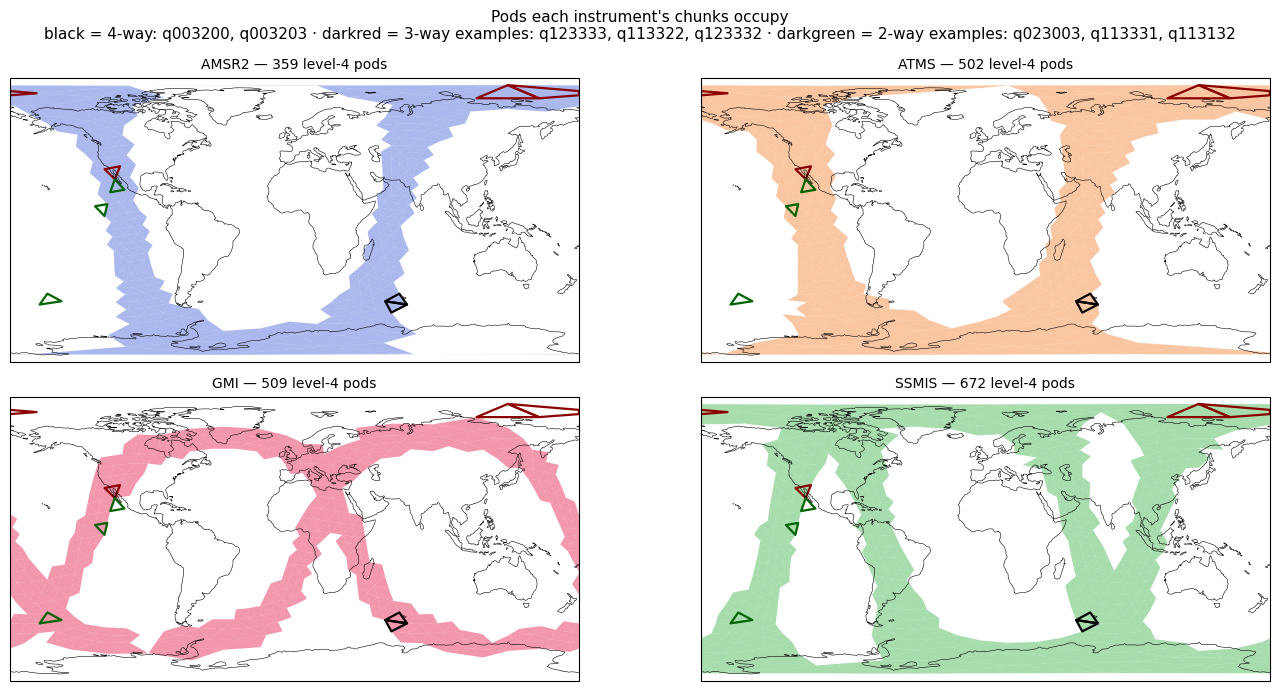

⏱  cell [5] took 2.31s


In [5]:
# Part 2's analytics again, scoped to the six-granule walkthrough set
# (`catalog`, loaded in the setup cell): the events and the 4-way pods that
# Parts 3–5 draw.
events = rendezvous_events(catalog, OVERLAP_DT)
pod_table = overlap_pod_table(events)
widest = max(pod_table.columns)
quad_pods = list(pod_table[pod_table[widest].gt(0)].index)
print(f"six granules: {len(events)} events at Δt = 45 min, "
      f"{len(quad_pods)} pod(s) with a {widest}-way rendezvous: {', '.join(quad_pods)}")

examples_by_width = {
    n_way: rendezvous_examples(events, n_way, count=wanted,
                               metadata=demo_meta, window=OVERLAP_DT)
    for n_way, wanted in [(2, 3), (3, 3), (4, 2)]
}
outlines = [
    (quad_pods, 'black', f'{widest}-way'),
    ([p for p, _, _ in examples_by_width[3]], 'darkred', '3-way examples'),
    ([p for p, _, _ in examples_by_width[2]], 'darkgreen', '2-way examples'),
]
fig = plot_pod_coverage(catalog, highlight=outlines)


## Part 4 — Rendezvous up close

Still on the **six selected granules**: the two cases below are the tightest
pair and the one 4-way rendezvous in that set, at the pixel level. The
figures draw each instrument's **first scan group only** (`GMI_S1`,
`SSMIS_S1`, …) so that one swath is one set of scan lines; the tables list
the other scan groups' counts beside it.

A rendezvous must satisfy **both** criteria — same pod *and* same time
window — so each figure shows both: on the left, the data-element locations
(QL27 trixels) inside the pod; on the right, each instrument's overpass
interval on the time axis. First the closest 2-way rendezvous in the data —
GMI and SSMIS covering the same pod back to back — then the main attraction:
the pod where **all four** instruments meet within the 45-minute window — each drawn with the
window its case needs: Δt = 15 minutes is already enough for the tight pair,
and only the 4-way needs the full 45.

Rendezvous here is performed at the **pod level** — a fast but broad way to
find overlaps between instruments' coverages. Once found, the STARE hierarchy
can be leveraged again to refine them to exact **data-element-level**
overlaps.


GT(_tbl_data=  scan group  data elements               other scan groups pass start  \
0     GMI_S1           4505                        S2: 4930   12:54:34   
1   SSMIS_S1           1325  S2: 1327 · S3: 2775 · S4: 2688   12:56:53   

   pass end  
0  12:56:43  
1  12:59:30  , _body=<great_tables._gt_data.Body object at 0x344f67140>, _boxhead=Boxhead([ColInfo(var='scan group', type=<ColInfoTypeEnum.default: 1>, column_label='Scan group', column_align='left', column_width=None), ColInfo(var='data elements', type=<ColInfoTypeEnum.default: 1>, column_label='Data elements', column_align='right', column_width=None), ColInfo(var='other scan groups', type=<ColInfoTypeEnum.default: 1>, column_label='Other scan groups', column_align='left', column_width=None), ColInfo(var='pass start', type=<ColInfoTypeEnum.default: 1>, column_label='Pass start', column_align='right', column_width=None), ColInfo(var='pass end', type=<ColInfoTypeEnum.default: 1>, column_label='Pass end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x344b445f0>, _spanners=Spanners([]), _heading=Heading(title='Pod q023003 — a 2-way rendezvous', subtitle='first scan group of each instrument, in order of arrival, all inside Δt = 15 min; the rendezvous completes 2025-01-01 12:56:53', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x346473980>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3464733b0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346473bc0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category

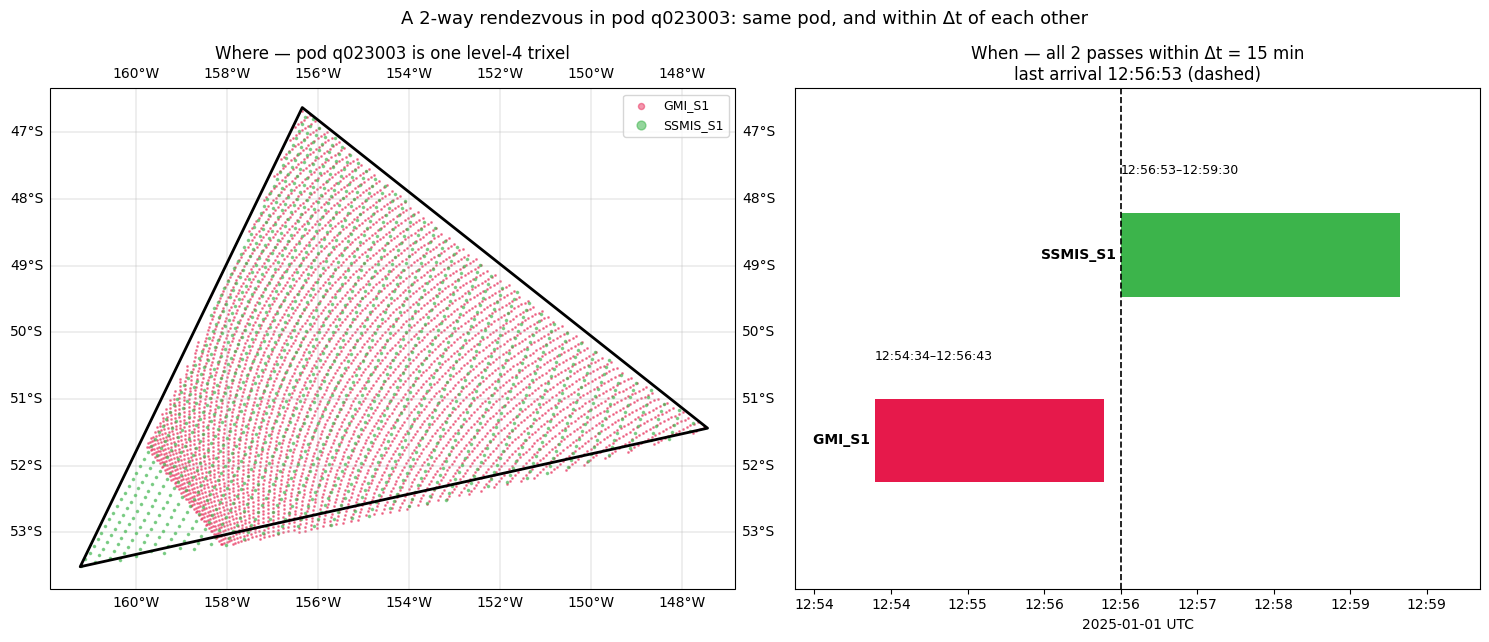

GT(_tbl_data=  scan group  data elements                                other scan groups  \
0   SSMIS_S1             92                       S2: 89 · S3: 108 · S4: 150   
1   AMSR2_S1            159  S2: 156 · S3: 155 · S4: 155 · S5: 299 · S6: 178   
2    ATMS_S1            143                                          S2: 141   
3     GMI_S1           3776                                         S2: 3363   

  pass start  pass end  
0   21:28:59  21:30:04  
1   21:46:28  21:47:13  
2   21:47:39  21:49:31  
3   22:13:52  22:16:30  , _body=<great_tables._gt_data.Body object at 0x34645e8d0>, _boxhead=Boxhead([ColInfo(var='scan group', type=<ColInfoTypeEnum.default: 1>, column_label='Scan group', column_align='left', column_width=None), ColInfo(var='data elements', type=<ColInfoTypeEnum.default: 1>, column_label='Data elements', column_align='right', column_width=None), ColInfo(var='other scan groups', type=<ColInfoTypeEnum.default: 1>, column_label='Other scan groups', column_align='left', column_width=None), ColInfo(var='pass start', type=<ColInfoTypeEnum.default: 1>, column_label='Pass start', column_align='right', column_width=None), ColInfo(var='pass end', type=<ColInfoTypeEnum.default: 1>, column_label='Pass end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1128643e0>, _spanners=Spanners([]), _heading=Heading(title='Pod q003200 — a 4-way rendezvous', subtitle='first scan group of each instrument, in order of arrival, all inside Δt = 45 min; the rendezvous completes 2025-01-01 22:13:52', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x34635ad50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346359550>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3463585f0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='valu

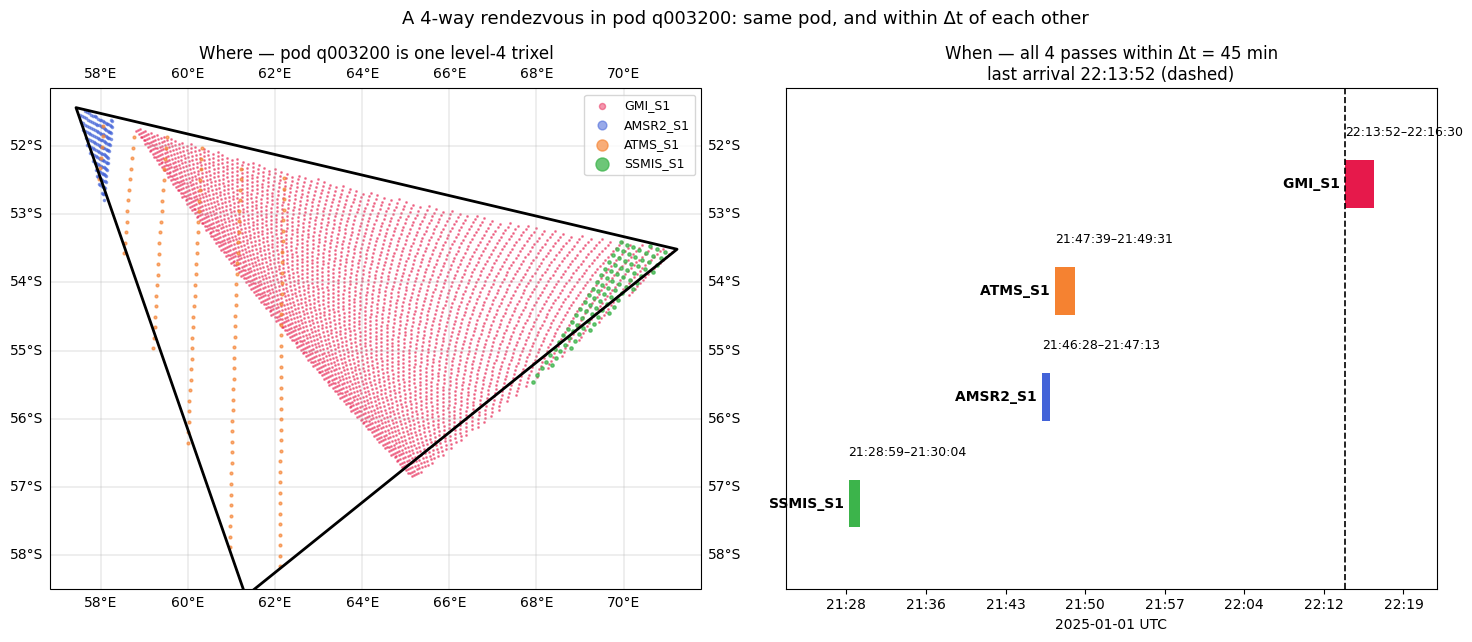

⏱  cell [6] took 14.06s


In [6]:
# Each case is drawn with the window its story needs: the GMI+SSMIS pair is
# so tight it already rendezvouses at the smallest window tried, 15 min --
# drawn at 45 min the two back-to-back passes would huddle at the edge of a
# mostly-empty 90-minute axis. Only the 4-way needs the full 45.
cases = [(examples_by_width[2][0], pd.Timedelta(minutes=15)),
         (examples_by_width[widest][0], OVERLAP_DT)]
for (pod, meeting, _), case_dt in cases:
    window = (meeting - case_dt, meeting + case_dt)
    # One download per scan group, kept per scan group; the figure draws S1.
    swath_pixels = pod_pixels(demo, demo_meta, pod, window, fold=False)
    first_group = {ds: px for ds, px in swath_pixels.items() if ds.endswith('_S1')}
    arrival = pd.DataFrame([
        {'scan group': ds,
         'data elements': len(px),
         'other scan groups': ' · '.join(
             f"{other.split('_', 1)[1]}: {len(opx)}"
             for other, opx in sorted(swath_pixels.items())
             if fold_instrument(other) == fold_instrument(ds) and other != ds),
         'pass start': px['timestamp'].min().strftime('%H:%M:%S'),
         'pass end': px['timestamp'].max().strftime('%H:%M:%S')}
        for ds, px in sorted(first_group.items(),
                             key=lambda kv: kv[1]['timestamp'].min())
    ])
    display(
        GT(arrival)
        .tab_header(title=f"Pod {pod} — a {len(first_group)}-way rendezvous",
                    subtitle="first scan group of each instrument, in order of arrival, "
                             f"all inside Δt = {int(case_dt.total_seconds() // 60)} min; "
                             "the rendezvous completes "
                             f"{meeting.strftime('%Y-%m-%d %H:%M:%S')}")
    )
    fig = plot_rendezvous(pod, first_group, meeting, case_dt)
    display(fig)
    plt.close(fig)


## Part 5 — Rendezvous over a region of interest

Still on the **six selected granules** (Part 5.1 repeats this query against
the whole store). The counts and tables are the query's full answer — every
scan group; the second figure draws each instrument's **first scan group**
only, labelled `GMI_S1`, `SSMIS_S1`, … At last, a closer-to-the-real-world scenario: rendezvous over a
**user-defined region** in a **specified time window** — a spatial query for
the region against the pods, ANDed with a temporal query for the window. The
region of interest here is a bounding box covering the 4-way pod, first
converted into a STARE cover of trixels — STARE's adaptive resolution at
work; the window is the rendezvous itself, ± Δt. The contrast between the
criteria makes the AND visible: SSMIS also flew over this same region on a
*morning* orbit, outside the time window, and the period filter drops exactly
those chunks. Two figures illustrate it:
first the region itself — the bbox and the STARE cover it becomes — and,
after the counts, the *result*: the data elements the query returns (whole
chunks, pod-level granularity, so they extend past the bbox) beside every
spatially-selected chunk's time span, with the greyed-out morning pass far
outside the shaded window.


GT(_tbl_data=           criterion                                              value
0   Region (spatial)  bbox around pod q003200's trixel — lon [56.0, ...
1  Window (temporal)  2025-01-01 21:28:52 → 22:58:52 — the 4-way mee..., _body=<great_tables._gt_data.Body object at 0x344ebd6d0>, _boxhead=Boxhead([ColInfo(var='criterion', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='value', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x17781c170>, _spanners=Spanners([]), _heading=Heading(title='The region-of-interest query', subtitle='a spatial criterion AND a temporal criterion', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x344bcf3b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x344bce000>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x344bcd190>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, ca

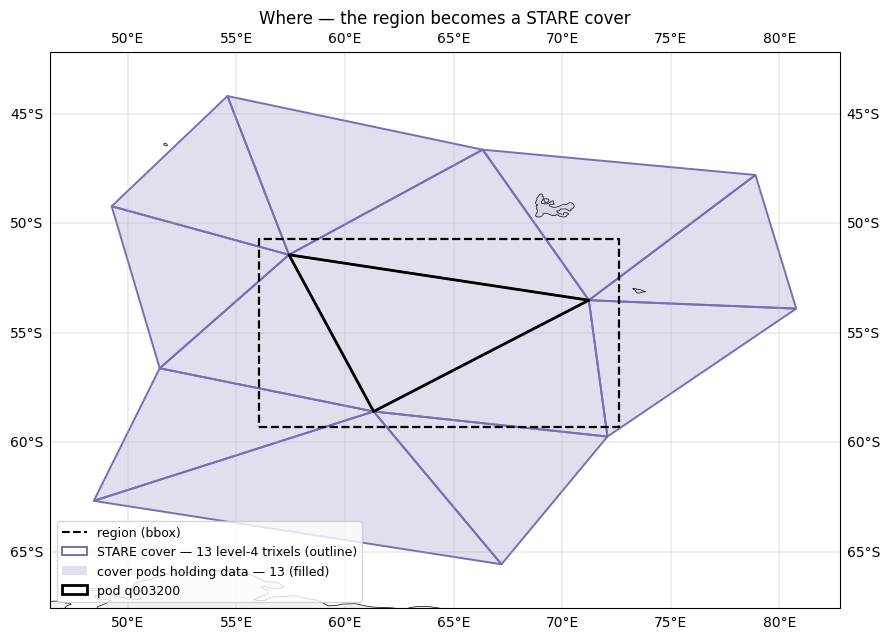

GT(_tbl_data=                                           criterion  chunks
0  Temporal only — whole demo footprint in the wi...    1478
1        Spatial only — this region, any time of day     154
2                               Spatial AND temporal     116, _body=<great_tables._gt_data.Body object at 0x346667ad0>, _boxhead=Boxhead([ColInfo(var='criterion', type=<ColInfoTypeEnum.default: 1>, column_label='Criterion', column_align='left', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x346664170>, _spanners=Spanners([]), _heading=Heading(title='One query, both filters', subtitle='the spatial-only surplus is the SSMIS morning pass over the same region', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x346665100>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346667e30>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x34666dfd0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px'

GT(_tbl_data=  instrument  spatial_only  both_filters          first_start  \
0      AMSR2            48            48  2025-01-01 21:43:37   
1       ATMS            20            20  2025-01-01 21:45:33   
2        GMI            18            18  2025-01-01 22:11:52   
3      SSMIS            68            30  2025-01-01 21:26:18   

              last_end  
0  2025-01-01 21:50:23  
1  2025-01-01 21:51:31  
2  2025-01-01 22:17:43  
3  2025-01-01 21:33:04  , _body=<great_tables._gt_data.Body object at 0x346522150>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='spatial_only', type=<ColInfoTypeEnum.default: 1>, column_label='Spatial only', column_align='right', column_width=None), ColInfo(var='both_filters', type=<ColInfoTypeEnum.default: 1>, column_label='Both filters', column_align='right', column_width=None), ColInfo(var='first_start', type=<ColInfoTypeEnum.default: 1>, column_label='First t_start', column_align='right', column_width=None), ColInfo(var='last_end', type=<ColInfoTypeEnum.default: 1>, column_label='Last t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x346214d70>, _spanners=Spanners([]), _heading=Heading(title='Surviving chunks by instrument', subtitle='in 13 pod(s), among them the 4-way pod q003200, q003203', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x344bccbc0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x344bcce90>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x344bce5d0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True

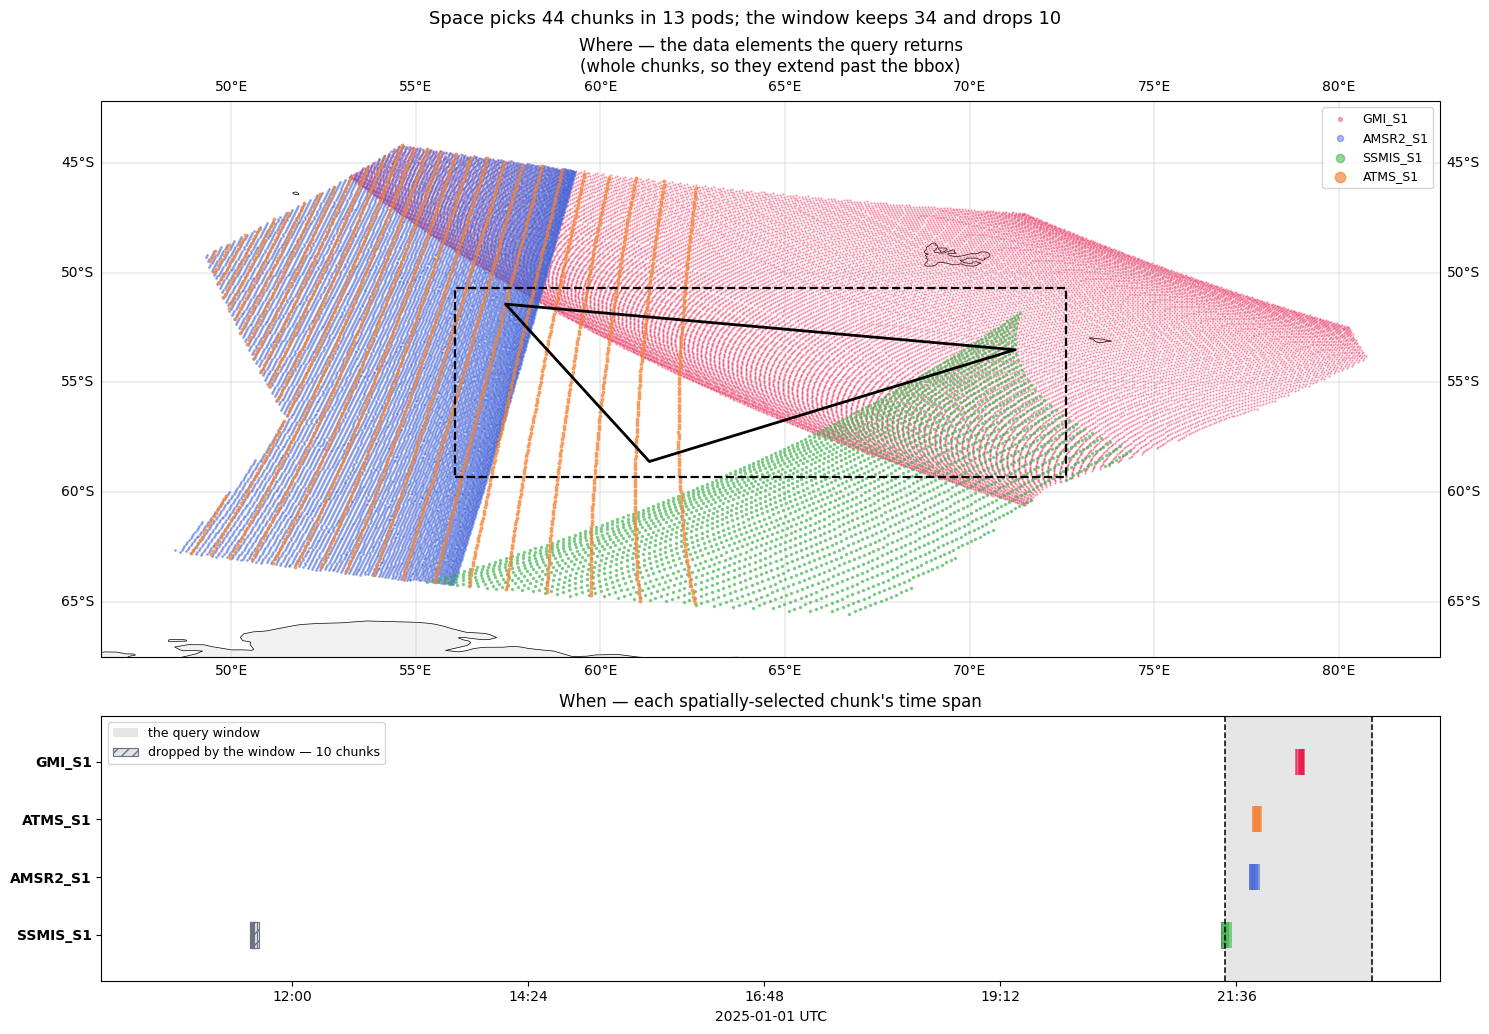

GT(_tbl_data=        kind                                               step    seconds  \
0      local  bounding box around the pod trixel → STARE cov...   0.003093   
1    display                             render the query table   0.003836   
2      query  spatial only — chunks in the cover, any time (...  22.067087   
3       plot  build figure 4 — the bbox and its STARE cover ...   0.063294   
4    display                                    render figure 4   0.245584   
5      query  temporal only — the whole walkthrough footprin...   0.999556   
6      query     spatial AND temporal — the region query itself   7.284743   
7    display                          render the criteria table   0.005837   
8      local                  per-instrument survivors (pandas)   0.005084   
9    display                    render the per-instrument table   0.009217   
10     local  keep the first scan group of each instrument f...   0.001450   
11  download  read the 34 surviving S1 chunks from S3 (Parquet)  16.174909   
12      plot  build figure 5 — S1 data elements + S1 chunk t...   0.084094   
13   display                                    render figure 5   0.173361   

       share  
0   0.000066  
1   0.000081  
2   0.468305  
3   0.001343  
4   0.005212  
5   0.021212  
6   0.154596  
7   0.000124  
8   0.000108  
9   0.000196  
10  0.000031  
11  0.343262  
12  0.001785  
13  0.003679  , _body=<great_tables._gt_data.Body object at 0x346985a60>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x34653a030>, _spanners=Spanners([]), _heading=Heading(title="Where this cell's time went — Part 5", subtitle='47.1 s over 14 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x34676bfe0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3465883e0>, _source_notes=['by kind — local: 0.0 s · display: 0.4 s · query: 30.4 s · plot: 0.1 s · download: 16.2 s'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346aec170>, _formats=[<great_tables._gt_data.FormatInfo object at 0x344c1a990>, <great_tables._gt_data.FormatInfo object at 0x34654eb40>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', typ

⏱  cell [7] took 47.14s


In [7]:
T = StepTimer()
pod, meeting, _ = examples_by_width[widest][0]
with T.step('local', 'bounding box around the pod trixel → STARE cover (13 SIDs)'):
    lon_min, lat_min, lon_max, lat_max = pod_trixels([pod]).total_bounds
    # Pad the box ~10% so it holds the trixel with a margin instead of cutting
    # its corners — the largest pad whose level-4 cover is still the same 13
    # trixels, so every count below is unchanged.
    pad_lon, pad_lat = (lon_max - lon_min) * 0.10, (lat_max - lat_min) * 0.10
    lon_min, lon_max = lon_min - pad_lon, lon_max + pad_lon
    lat_min, lat_max = lat_min - pad_lat, lat_max + pad_lat
    location_sids = demo.get_sids_for_bbox(lon_min, lat_min, lon_max, lat_max,
                                           level=STARE_LEVEL)
    window = (meeting - OVERLAP_DT, meeting + OVERLAP_DT)
query = pd.DataFrame([
    {'criterion': 'Region (spatial)',
     'value': f"bbox around pod {pod}'s trixel — "
              f"lon [{lon_min:.1f}, {lon_max:.1f}], "
              f"lat [{lat_min:.1f}, {lat_max:.1f}] "
              f"→ {len(location_sids)} level-{STARE_LEVEL} cover SIDs"},
    {'criterion': 'Window (temporal)',
     'value': f"{window[0].strftime('%Y-%m-%d %H:%M:%S')} → "
              f"{window[1].strftime('%H:%M:%S')} "
              f"— the {widest}-way meeting ± Δt"},
])
with T.step('display', 'render the query table'):
    display(
        GT(query)
        .tab_header(title="The region-of-interest query",
                    subtitle="a spatial criterion AND a temporal criterion")
        .cols_label(criterion="", value="")
    )

with T.step('query', 'spatial only — chunks in the cover, any time (catalog)'):
    spatial_only = demo.find_intersecting_data(location_sids, INSTRUMENTS,
                                               path_prefix=S3_PREFIX)
with T.step('plot', 'build figure 4 — the bbox and its STARE cover (cartopy)'):
    fig = plot_region_cover((lon_min, lat_min, lon_max, lat_max), location_sids,
                            spatial_only, highlight_pod=pod)
with T.step('display', 'render figure 4'):
    display(fig)
    plt.close(fig)

with T.step('query', 'temporal only — the whole walkthrough footprint in the window'):
    temporal_only = load_s3_metadata(period=window, path_prefix=S3_PREFIX)
with T.step('query', 'spatial AND temporal — the region query itself'):
    both = demo.find_intersecting_data(location_sids, INSTRUMENTS, period=window,
                                       path_prefix=S3_PREFIX)
criteria = pd.DataFrame([
    {'criterion': 'Temporal only — whole demo footprint in the window',
     'chunks': len(temporal_only)},
    {'criterion': 'Spatial only — this region, any time of day',
     'chunks': len(spatial_only)},
    {'criterion': 'Spatial AND temporal', 'chunks': len(both)},
])
with T.step('display', 'render the criteria table'):
    display(
        GT(criteria)
        .tab_header(title="One query, both filters",
                    subtitle="the spatial-only surplus is the SSMIS morning pass "
                             "over the same region")
    )

with T.step('local', 'per-instrument survivors (pandas)'):
    per_instrument = (
        both.assign(instrument=both['Dataset'].map(fold_instrument))
            .groupby('instrument')
            .agg(both_filters=('podcode', 'size'),
                 first_start=('t_start', 'min'),
                 last_end=('t_end', 'max'))
    )
    per_instrument.insert(0, 'spatial_only', (
        spatial_only.assign(instrument=spatial_only['Dataset'].map(fold_instrument))
        .groupby('instrument').size()
    ))
with T.step('display', 'render the per-instrument table'):
    display(
        GT(fmt_times(per_instrument.reset_index(), ('first_start', 'last_end')))
        .tab_header(title="Surviving chunks by instrument",
                    subtitle=f"in {both['podcode'].nunique()} pod(s), among them "
                             f"the {widest}-way pod "
                             + ', '.join(sorted(p for p in both['podcode'].unique()
                                                if p in quad_pods)))
        .cols_label(spatial_only="Spatial only", both_filters="Both filters",
                    first_start="First t_start", last_end="Last t_end")
    )

with T.step('local', 'keep the first scan group of each instrument for the figure'):
    both_s1 = both[both['Dataset'].str.endswith('_S1')]
    spatial_s1 = spatial_only[spatial_only['Dataset'].str.endswith('_S1')]
with T.step('download', f'read the {len(both_s1)} surviving S1 chunks from S3 (Parquet)'):
    region_passes = chunk_pixels(demo, both_s1, window, fold=False)
with T.step('plot', 'build figure 5 — S1 data elements + S1 chunk timeline'):
    fig = plot_region_result(region_passes, spatial_s1, window,
                             bbox=(lon_min, lat_min, lon_max, lat_max),
                             highlight_pod=pod, fold=False)
with T.step('display', 'render figure 5'):
    display(fig)
    plt.close(fig)
display(T.table("Where this cell's time went — Part 5"))


### Part 5.1 — The same region query against the whole store

Exactly Part 5's query — the same bounding box, the same STARE cover, the
same 90-minute window around the 4-way meeting — but now against the
**whole catalog** instead of the six-granule root. Two things change.

Space alone now picks every pass of every instrument over those 13 pods in
three months — six figures of chunks rather than 154 — so the spatial half is
answered pod by pod: one thin, index-backed load per cover pod code. (The
walkthrough's helper filters pods *after* loading an instrument's metadata,
which is fine for six granules and not for twelve million rows.) The window
then does the real work. And the result grows: the 116 chunks from before
are still there, plus what the bulk store holds for that same place and
hour that the curated set did not — the table under the counts says where
the extra chunks come from.

The figures mirror Part 5's — first scan groups only, as there. The time
axis of the second one shows the **query day** only; over the whole quarter
the spatially-selected chunks would paint the axis solid.


GT(_tbl_data=                                           criterion  chunks
0  Temporal only — everything in the window, anyw...    7443
1  Spatial only — this region, any time in the qu...  102641
2          Spatial only — this region, the query day     960
3                               Spatial AND temporal     132, _body=<great_tables._gt_data.Body object at 0x34628b5f0>, _boxhead=Boxhead([ColInfo(var='criterion', type=<ColInfoTypeEnum.default: 1>, column_label='Criterion', column_align='left', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x37a44a570>, _spanners=Spanners([]), _heading=Heading(title='One query, both filters — the whole store', subtitle='Part 5 found 116 chunks in the six-granule root; the whole store gives 132', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x346b980e0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346b997c0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3465862d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x346b9adb0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsIn

GT(_tbl_data=                                  root instrument platform  chunks
0  Q1 2025 bulk ingest (cloud workers)       ATMS   NOAA20      16
1  six-granule walkthrough (Parts 2-5)      AMSR2   GCOMW1      48
2  six-granule walkthrough (Parts 2-5)       ATMS   NOAA21      20
3  six-granule walkthrough (Parts 2-5)        GMI      GPM      18
4  six-granule walkthrough (Parts 2-5)      SSMIS      F18      30, _body=<great_tables._gt_data.Body object at 0x37a44a990>, _boxhead=Boxhead([ColInfo(var='root', type=<ColInfoTypeEnum.default: 1>, column_label='Storage root', column_align='left', column_width=None), ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='platform', type=<ColInfoTypeEnum.default: 1>, column_label='Platform', column_align='left', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x346193b90>, _spanners=Spanners([]), _heading=Heading(title='Where the surviving chunks come from', subtitle='the six-granule root plus what the bulk store adds for the same place and hour', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3465b49b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346a62810>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346a63ce0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=Option

GT(_tbl_data=  instrument  spatial_quarter  spatial_day  both_filters          first_start  \
0      AMSR2            22632          246            48  2025-01-01 21:43:37   
1       ATMS            56181          452            36  2025-01-01 21:45:33   
2        GMI             8662           90            18  2025-01-01 22:11:52   
3      SSMIS            15166          172            30  2025-01-01 21:26:18   

              last_end  
0  2025-01-01 21:50:23  
1  2025-01-01 22:38:43  
2  2025-01-01 22:17:43  
3  2025-01-01 21:33:04  , _body=<great_tables._gt_data.Body object at 0x37e31b650>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='spatial_quarter', type=<ColInfoTypeEnum.default: 1>, column_label='Spatial only (quarter)', column_align='right', column_width=None), ColInfo(var='spatial_day', type=<ColInfoTypeEnum.default: 1>, column_label='Spatial only (query day)', column_align='right', column_width=None), ColInfo(var='both_filters', type=<ColInfoTypeEnum.default: 1>, column_label='Both filters', column_align='right', column_width=None), ColInfo(var='first_start', type=<ColInfoTypeEnum.default: 1>, column_label='First t_start', column_align='right', column_width=None), ColInfo(var='last_end', type=<ColInfoTypeEnum.default: 1>, column_label='Last t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x37e31bcb0>, _spanners=Spanners([]), _heading=Heading(title='Surviving chunks by instrument — the whole store', subtitle='in 13 pod(s) of the cover', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x37e31aff0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x37e31af60>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x37e31ab10>, _formats=[<great_tables._gt_data.FormatInfo object at 0x37e31aa50>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss

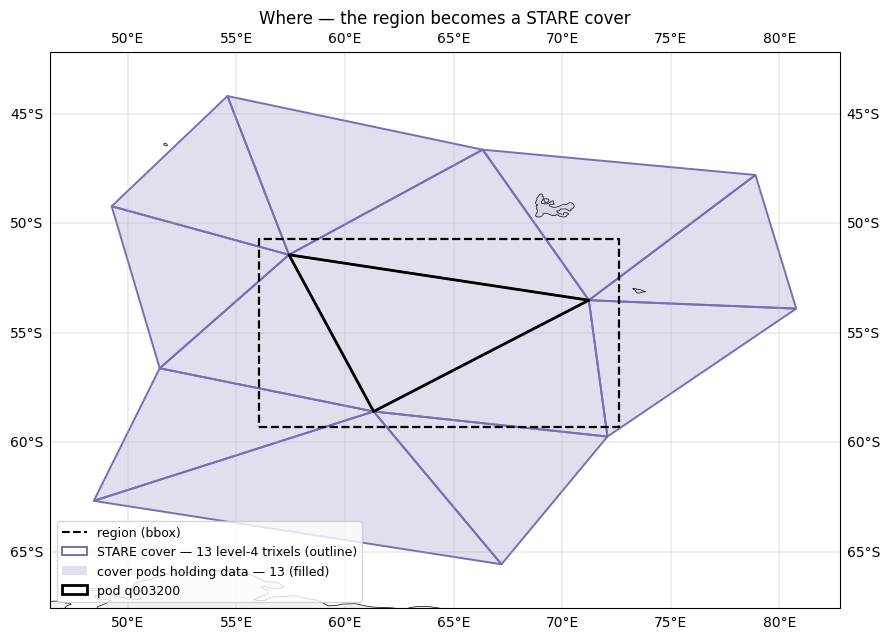

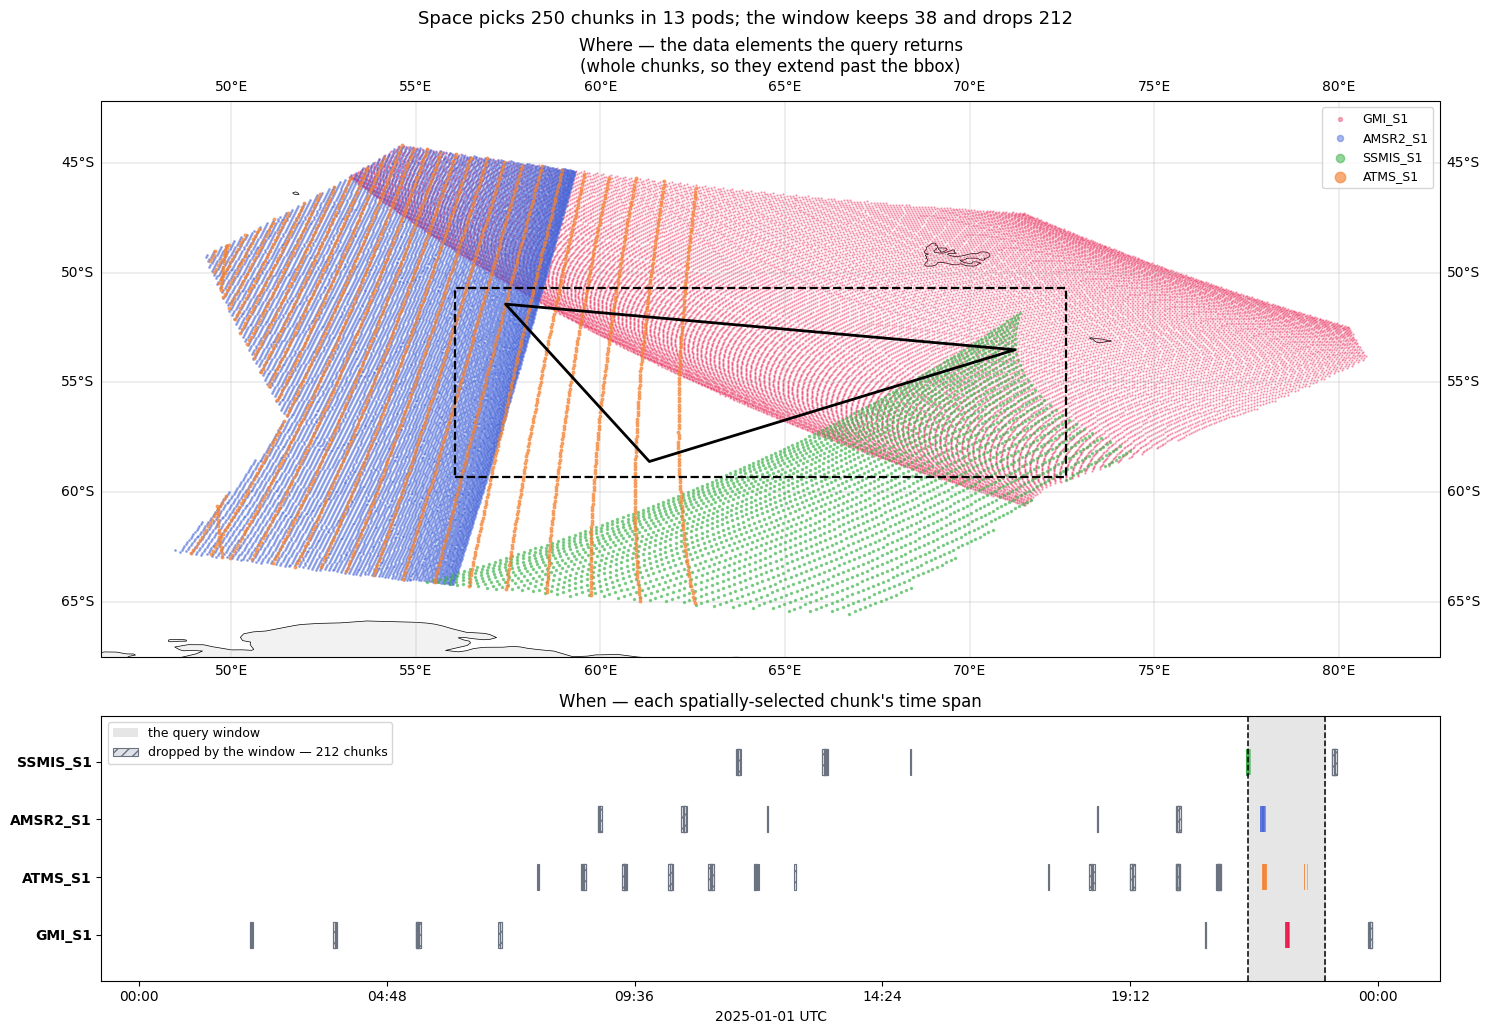

GT(_tbl_data=        kind                                               step    seconds  \
0      local                cover SIDs → the 13 cover pod codes   0.000029   
1      query  spatial only, whole quarter — 13 pod-code cata...  30.672194   
2      local  restrict the spatial pick to the query day (fo...   0.001446   
3      query  temporal only — the whole catalog inside the w...   1.187845   
4      query  spatial AND temporal — the region query, whole...   7.569765   
5    display                          render the criteria table   0.004676   
6      local  where the surviving chunks come from (root × p...   0.002560   
7    display                            render the origin table   0.004948   
8      local                  per-instrument survivors (pandas)   0.044430   
9    display                    render the per-instrument table   0.008113   
10      plot  build figure 6 — the cover, with every cover p...   0.097260   
11   display                                    render figure 6   0.093623   
12     local  keep the first scan group of each instrument f...   0.000941   
13  download  read the 38 surviving S1 chunks from S3 (Parquet)  17.420384   
14      plot  build figure 7 — S1 data elements + the query ...   0.142458   
15   display                                    render figure 7   0.235792   

           share  
0   5.124371e-07  
1   5.335551e-01  
2   2.515736e-05  
3   2.066304e-02  
4   1.316791e-01  
5   8.133219e-05  
6   4.453947e-05  
7   8.607824e-05  
8   7.728790e-04  
9   1.411340e-04  
10  1.691880e-03  
11  1.628608e-03  
12  1.637053e-05  
13  3.030345e-01  
14  2.478110e-03  
15  4.101703e-03  , _body=<great_tables._gt_data.Body object at 0x379cb1fa0>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x346b48650>, _spanners=Spanners([]), _heading=Heading(title="Where this cell's time went — Part 5.1", subtitle='57.5 s over 16 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x379cb1820>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x379c66540>, _source_notes=['by kind — local: 0.0 s · query: 39.4 s · display: 0.3 s · plot: 0.2 s · download: 17.4 s'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x379dfe300>, _formats=[<great_tables._gt_data.FormatInfo object at 0x379dd2f30>, <great_tables._gt_data.FormatInfo object at 0x376017fb0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value=

⏱  cell [8] took 57.50s


In [8]:
T = StepTimer()
# Same region, cover and window as Part 5 (pod, meeting, location_sids,
# window, lon/lat bounds are still defined).
with T.step('local', 'cover SIDs → the 13 cover pod codes'):
    cover_pods = sorted({sid_to_podcode(int(s)) for s in location_sids})
with T.step('query', f'spatial only, whole quarter — {len(cover_pods)} pod-code catalog reads'):
    spatial_q = pd.concat([load_s3_temporal_catalog(podcode_prefix=p) for p in cover_pods],
                          ignore_index=True)
with T.step('local', 'restrict the spatial pick to the query day (for the timeline)'):
    day = (window[0].normalize(), window[0].normalize() + pd.Timedelta(days=1))
    spatial_day = spatial_q[(spatial_q['t_start'] <= day[1]) & (spatial_q['t_end'] >= day[0])]
with T.step('query', 'temporal only — the whole catalog inside the window'):
    temporal_q = load_s3_metadata(period=window)
with T.step('query', 'spatial AND temporal — the region query, whole catalog'):
    both_q = demo.find_intersecting_data(location_sids, INSTRUMENTS, period=window)

criteria_q = pd.DataFrame([
    {'criterion': 'Temporal only — everything in the window, anywhere on Earth',
     'chunks': len(temporal_q)},
    {'criterion': 'Spatial only — this region, any time in the quarter',
     'chunks': len(spatial_q)},
    {'criterion': 'Spatial only — this region, the query day', 'chunks': len(spatial_day)},
    {'criterion': 'Spatial AND temporal', 'chunks': len(both_q)},
])
with T.step('display', 'render the criteria table'):
    display(
        GT(criteria_q)
        .tab_header(title="One query, both filters — the whole store",
                    subtitle=f"Part 5 found {len(both)} chunks in the six-granule "
                             f"root; the whole store gives {len(both_q)}")
        .fmt_integer(columns='chunks')
    )

with T.step('local', 'where the surviving chunks come from (root × platform)'):
    origin = pd.DataFrame({
        'root': [ROOTS.get(r, r) for r in both_q['group_path'].str.rsplit('/', n=1).str[0]],
        'platform': [parse_chunk_filename(p)[1].split('.')[1] for p in both_q['group_path']],
        'instrument': both_q['Dataset'].map(fold_instrument),
    })
    origin = (origin.groupby(['root', 'instrument', 'platform']).size()
                    .rename('chunks').reset_index())
with T.step('display', 'render the origin table'):
    display(
        GT(origin)
        .tab_header(title="Where the surviving chunks come from",
                    subtitle="the six-granule root plus what the bulk store adds "
                             "for the same place and hour")
        .cols_label(root="Storage root")
    )

with T.step('local', 'per-instrument survivors (pandas)'):
    inst_q = both_q['Dataset'].map(fold_instrument)
    per_instrument_q = (
        both_q.assign(instrument=inst_q).groupby('instrument')
              .agg(both_filters=('podcode', 'size'),
                   first_start=('t_start', 'min'), last_end=('t_end', 'max'))
    )
    per_instrument_q.insert(0, 'spatial_day', spatial_day.assign(
        instrument=spatial_day['Dataset'].map(fold_instrument)).groupby('instrument').size())
    per_instrument_q.insert(0, 'spatial_quarter', spatial_q.assign(
        instrument=spatial_q['Dataset'].map(fold_instrument)).groupby('instrument').size())
with T.step('display', 'render the per-instrument table'):
    display(
        GT(fmt_times(per_instrument_q.reset_index(), ('first_start', 'last_end')))
        .tab_header(title="Surviving chunks by instrument — the whole store",
                    subtitle=f"in {both_q['podcode'].nunique()} pod(s) of the cover")
        .fmt_integer(columns=['spatial_quarter', 'spatial_day', 'both_filters'])
        .cols_label(spatial_quarter="Spatial only (quarter)",
                    spatial_day="Spatial only (query day)", both_filters="Both filters",
                    first_start="First t_start", last_end="Last t_end")
    )

with T.step('plot', 'build figure 6 — the cover, with every cover pod holding data'):
    fig = plot_region_cover((lon_min, lat_min, lon_max, lat_max), location_sids,
                            spatial_q, highlight_pod=pod)
with T.step('display', 'render figure 6'):
    display(fig)
    plt.close(fig)
with T.step('local', 'keep the first scan group of each instrument for the figure'):
    both_q_s1 = both_q[both_q['Dataset'].str.endswith('_S1')]
    spatial_day_s1 = spatial_day[spatial_day['Dataset'].str.endswith('_S1')]
with T.step('download', f'read the {len(both_q_s1)} surviving S1 chunks from S3 (Parquet)'):
    region_passes_q = chunk_pixels(demo, both_q_s1, window, fold=False)
with T.step('plot', 'build figure 7 — S1 data elements + the query day\'s S1 chunk timeline'):
    fig = plot_region_result(region_passes_q, spatial_day_s1, window,
                             bbox=(lon_min, lat_min, lon_max, lat_max),
                             highlight_pod=pod, fold=False)
with T.step('display', 'render figure 7'):
    display(fig)
    plt.close(fig)
display(T.table("Where this cell's time went — Part 5.1"))


## Part 6 — Performance at scale

Part 2 covered the whole quarter in one go; Parts 3–5 ran on six granules.
What does the engine cost as the scope grows? Part 2's pipeline is repeated
on the bulk-store root — 7,344 granules, 12.4 million chunks — at four scopes — a day, a week, a
month, the quarter — timing each stage: the **catalog read** (four columns per
chunk — pod code, scan group, `t_start`, `t_end` — and nothing else leaves the
database), the **meeting search** (`rendezvous_events`: one pass over each pod's
chunks in time order), and the **aggregation** into the pair matrix and the
per-pod table.

Two things to watch. The analytics never open a chunk — S3 is not touched, so
the cost is the catalog's, not the data volume's. And the search is **flat in
n**: the 2-way, 3-way and 4-way counts all fall out of the *same* single
pass over the catalog, at the same cost — there is no pairwise join whose cost grows with the
number of instruments.


In [9]:
T = StepTimer()
PART6_DT = pd.Timedelta(minutes=10)             # Part 6 window (Parts 3-5 keep OVERLAP_DT)
PART6_MIN = int(PART6_DT.total_seconds() // 60)
SCOPES = [
    ('one day (Feb 5)',     (pd.Timestamp('2025-02-05'), pd.Timestamp('2025-02-06'))),
    ('one week (Feb 5–11)', (pd.Timestamp('2025-02-05'), pd.Timestamp('2025-02-12'))),
    ('one month (Feb)',     (pd.Timestamp('2025-02-01'), pd.Timestamp('2025-03-01'))),
    ('the quarter',         None),
]
perf_rows = []
for label, period in SCOPES:
    with T.step('query', f'read 4 catalog columns — {label}'):
        scoped = load_s3_temporal_catalog(path_prefix=STORE_PREFIX, period=period)
    t_load = T.last
    with T.step('local', f'find meetings (rendezvous_events) — {label}'):
        ev = rendezvous_events(scoped, PART6_DT)
    t_sweep = T.last
    with T.step('local', f'aggregate (matrix + pod table) — {label}'):
        mat, tab = overlap_matrix(ev), overlap_pod_table(ev)
    t_agg = T.last
    row = {'scope': label, 'chunks': len(scoped), 'load_s': t_load,
           'sweep_s': t_sweep, 'aggregate_s': t_agg, 'events': len(ev)}
    for n in (2, 3, 4):
        row[f'{n}-way'] = int(tab[n].gt(0).sum()) if n in tab.columns else 0
    perf_rows.append(row)
    if period is None:                      # keep the quarter's results
        quarter_events, quarter_matrix, quarter_table = ev, mat, tab
    del scoped
perf = pd.DataFrame(perf_rows)
with T.step('display', 'render the scope × stage table'):
    display(
        GT(perf)
        .tab_header(title=f"The rendezvous engine at scale — bulk-store root, Δt = {PART6_MIN} min",
                    subtitle="the same three stages as Part 2, on a day, a week, a month "
                             "and the whole quarter of 2025; no chunk is ever opened")
        .fmt_integer(columns=['chunks', 'events'])
        .fmt_number(columns=['load_s', 'sweep_s', 'aggregate_s'], decimals=1)
        .tab_spanner(label="seconds", columns=['load_s', 'sweep_s', 'aggregate_s'])
        .tab_spanner(label="pods containing an n-way rendezvous",
                     columns=['2-way', '3-way', '4-way'])
        .cols_label(scope="", load_s="Read catalog", sweep_s="Find meetings", aggregate_s="Aggregate")
    )

with T.step('local', 'split the quarter\'s events by n-way (pandas)'):
    quarter_sweep_s = perf.loc[perf['scope'] == 'the quarter', 'sweep_s'].iloc[0]
    widths = quarter_events['instruments'].map(len)
    flat = pd.DataFrame([
        {'width': f'{n}-way',
         'pods': int(quarter_table[n].gt(0).sum()),
         'events': int((widths == n).sum())}
        for n in (2, 3, 4)
    ])   # an event = one pass arriving at a pod while others are still active
with T.step('display', 'render the flat-in-n table'):
    display(
        GT(flat)
        .tab_header(title="Flat in n — one search answers 2-, 3- and 4-way at once",
                    subtitle=f"the quarter's {len(quarter_events):,} events in total, split by n — the three "
                             f"rows add up to it, all from the one {quarter_sweep_s:.1f} s search")
        .fmt_integer(columns=['pods', 'events'])
        .cols_label(width="", pods="Pods with an n-way", events="Events at n-way")
        .tab_source_note("an event is one pass arriving at a pod while other "
                         "instruments are still present there; n is how many "
                         "instruments are present at that moment, the arriving "
                         "one included; each event is counted once, at its own n")
    )

with T.step('local', 'shape the quarter matrix'):
    qm = quarter_matrix.astype(object)
    for instrument in qm.index:
        qm.loc[instrument, instrument] = '—'
    qm.insert(0, 'instrument', qm.index)
with T.step('display', 'render the quarter matrix'):
    display(
        GT(qm.reset_index(drop=True), rowname_col='instrument')
        .tab_header(title="Who met whom over the quarter — pods where each pair rendezvous",
                    subtitle=f"Δt = {PART6_MIN} min; of {8 * 4 ** STARE_LEVEL} level-{STARE_LEVEL} "
                             "pods — compare Part 2's 10-minute matrix")
    )
display(T.table("Where this cell's time went — Part 6"))


GT(_tbl_data=                 scope    chunks     load_s    sweep_s  aggregate_s   events  \
0      one day (Feb 5)    149779   1.603341   0.115178     0.036283    33813   
1  one week (Feb 5–11)   1037410   5.101006   0.890234     0.152435   207927   
2      one month (Feb)   4142972  12.949730   3.936488     0.539517   835684   
3          the quarter  12430463  36.320749  14.049200     1.451508  2335819   

   2-way  3-way  4-way  
0   2017    354      3  
1   2048   1371     13  
2   2048   1747     35  
3   2048   1983     65  , _body=<great_tables._gt_data.Body object at 0x34675d6a0>, _boxhead=Boxhead([ColInfo(var='scope', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='load_s', type=<ColInfoTypeEnum.default: 1>, column_label='Read catalog', column_align='right', column_width=None), ColInfo(var='sweep_s', type=<ColInfoTypeEnum.default: 1>, column_label='Find meetings', column_align='right', column_width=None), ColInfo(var='aggregate_s', type=<ColInfoTypeEnum.default: 1>, column_label='Aggregate', column_align='right', column_width=None), ColInfo(var='events', type=<ColInfoTypeEnum.default: 1>, column_label='Events', column_align='right', column_width=None), ColInfo(var='2-way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='right', column_width=None), ColInfo(var='3-way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='right', column_width=None), ColInfo(var='4-way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x37e2fdb20>, _spanners=Spanners([SpannerInfo(spanner_id='seconds', spanner_level=0, spanner_label='seconds', spanner_units=None, spanner_pattern=None, vars=['load_s', 'sweep_s', 'aggregate_s'], built=None), SpannerInfo(spanner_id='pods containing an n-way rendezvous', spanner_level=0, spanner_label='pods containing an n-way rendezvous', spanner_units=None, spanner_pattern=None, vars=['2-way', '3-way', '4-way'], built=None)]), _heading=Heading(title='The rendezvous engine at scale — bulk-store root, Δt = 10 min', subtitle='the same three stages as Part 2, on a day, a week, a month and the whole quarter of 2025; no chunk is ever opened', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x346b420f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346b42b40>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346b413d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3467e6e10>, <great_tables._gt_data.FormatInfo object at 0x3467e68d0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value

GT(_tbl_data=   width  pods   events                      cost
0  2-way  2048  2102716  
1  3-way  1983   232528  
2  4-way    65      575  , _body=<great_tables._gt_data.Body object at 0x3467e6b40>, _boxhead=Boxhead([ColInfo(var='width', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods with an n-way', column_align='right', column_width=None), ColInfo(var='events', type=<ColInfoTypeEnum.default: 1>, column_label='Events at n-way', column_align='right', column_width=None), ColInfo(var='cost', type=<ColInfoTypeEnum.default: 1>, column_label='Where the numbers came from', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x346b408f0>, _spanners=Spanners([]), _heading=Heading(title='Flat in n — one search answers 2-, 3- and 4-way at once', subtitle="the quarter's 2,335,819 events in total, split by n — the three rows add up to it", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3468593a0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346858680>, _source_notes=['an event is one pass arriving at a pod while other instruments are still present there; n is how many instruments are present at that moment, the arriving one included; each event is counted once, at its own n'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346727830>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3469c1220>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), 

GT(_tbl_data=  instrument AMSR2  ATMS   GMI SSMIS
0      AMSR2     —  2048  1976   473
1       ATMS  2048     —  1980   653
2        GMI  1976  1980     —  1963
3      SSMIS   473   653  1963     —, _body=<great_tables._gt_data.Body object at 0x3467e6420>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.stub: 2>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='AMSR2', type=<ColInfoTypeEnum.default: 1>, column_label='AMSR2', column_align='left', column_width=None), ColInfo(var='ATMS', type=<ColInfoTypeEnum.default: 1>, column_label='ATMS', column_align='left', column_width=None), ColInfo(var='GMI', type=<ColInfoTypeEnum.default: 1>, column_label='GMI', column_align='left', column_width=None), ColInfo(var='SSMIS', type=<ColInfoTypeEnum.default: 1>, column_label='SSMIS', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x346798ef0>, _spanners=Spanners([]), _heading=Heading(title='Who met whom over the quarter — pods where each pair rendezvous', subtitle="Δt = 10 min; of 2048 level-4 pods — compare Part 2's 10-minute matrix", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3469c0080>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3469c2c60>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3469c1eb0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=Tr

GT(_tbl_data=       kind                                               step    seconds  \
0     query           read 4 catalog columns — one day (Feb 5)   1.603341   
1     local  find meetings (rendezvous_events) — one day (F...   0.115178   
2     local   aggregate (matrix + pod table) — one day (Feb 5)   0.036283   
3     query       read 4 catalog columns — one week (Feb 5–11)   5.101006   
4     local  find meetings (rendezvous_events) — one week (...   0.890234   
5     local  aggregate (matrix + pod table) — one week (Feb...   0.152435   
6     query           read 4 catalog columns — one month (Feb)  12.949730   
7     local  find meetings (rendezvous_events) — one month ...   3.936488   
8     local   aggregate (matrix + pod table) — one month (Feb)   0.539517   
9     query               read 4 catalog columns — the quarter  36.320749   
10    local    find meetings (rendezvous_events) — the quarter  14.049200   
11    local       aggregate (matrix + pod table) — the quarter   1.451508   
12  display                     render the scope × stage table   0.010371   
13    local    split the quarter's events by n-way (pandas)   0.362006   
14  display                         render the flat-in-n table   0.005888   
15    local                           shape the quarter matrix   0.000311   
16  display                          render the quarter matrix   0.005476   

       share  
0   0.020680  
1   0.001486  
2   0.000468  
3   0.065794  
4   0.011482  
5   0.001966  
6   0.167029  
7   0.050774  
8   0.006959  
9   0.468475  
10  0.181211  
11  0.018722  
12  0.000134  
13  0.004669  
14  0.000076  
15  0.000004  
16  0.000071  , _body=<great_tables._gt_data.Body object at 0x346141fa0>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x346b43860>, _spanners=Spanners([]), _heading=Heading(title="Where this cell's time went — Part 6", subtitle='77.5 s over 17 steps, in the order they ran', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3466d2e40>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x346798170>, _source_notes=['by kind — query: 56.0 s · local: 21.5 s · display: 0.0 s'], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3467991c0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x34679b3b0>, <great_tables._gt_data.FormatInfo object at 0x3464bd460>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_colo

⏱  cell [9] took 77.56s


## Recap

In this video we demonstrated a construction of the STARE Parallel Optimized
Data Store, **STARE-PODS**. During the construction, a DBMS is used to
catalog the relevant metadata, and it supports **pod-level rendezvous
analytics** — often the first step in the integrative analysis of diverse
data. These rendezvous can be efficiently refined by leveraging the STARE
hierarchy to obtain data-element-level rendezvous. And the engine scales:
the whole quarter — twelve million chunks — loads in well under a minute and
its meetings are found in seconds, 2-, 3- and 4-way alike, without opening a single chunk.

Since the Parquet chunks' file names contain the pod codes, and their
contents the spatiotemporal information of the data, rendezvous analytics can
also be performed using the Parquet chunks alone — less efficiently than with
the database, but still better than the existing way.


## Run time

Every code cell above reported its own wall-clock time; here is the total
and where it went. A handful of cells account for nearly all of it, and each
is doing a whole quarter's work or opening chunks: the database's one pass
over the 12.5 M-row catalog for the inventory, Part 2's quarter load and
three meeting searches, Part 5's and Part 5.1's chunk downloads, and Part 6's four
scopes. Everything the
rendezvous engine itself does — Parts 1 and 2 on the walkthrough set, and
the meeting searches inside Part 6 — is seconds or less. (Parts 4 and 5 are the only
cells that open chunks; the rest is catalog only.) The store-inventory,
Part 2, Part 5, Part 5.1 and Part 6 cells each end with their own step-by-step breakdown —
query vs. download vs. local compute vs. plotting vs. rendering.


In [10]:
CELL_LABELS = {              # In[n] → what that cell does (cells run in order)
    1: 'setup — imports, config, the walkthrough catalog read',
    2: 'the data in the store — quarter summary + occupancy (server-side)',
    3: 'Part 1 — temporal catalog tables',
    4: 'Part 2 — quarter catalog read, Δt searches, matrix, drill-down',
    5: 'Part 3 — six-granule meeting search + coverage map (figure 1)',
    6: 'Part 4 — two rendezvous up close (figures 2–3, chunk downloads)',
    7: 'Part 5 — region-of-interest query (figures 4–5)',
    8: 'Part 5.1 — the same region query against the whole store (figures 6–7)',
    9: 'Part 6 — day / week / month / quarter timings',
}
timings = pd.DataFrame({'cell': list(CELL_TIMINGS), 'seconds': list(CELL_TIMINGS.values())})
timings['what'] = timings['cell'].map(CELL_LABELS).fillna('')
total = timings['seconds'].sum()
timings['share'] = timings['seconds'] / total
display(
    GT(timings[['cell', 'what', 'seconds', 'share']])
    .tab_header(title="Where the time went",
                subtitle=f"{len(timings)} code cells, {total:.0f} s total "
                         f"({total / 60:.1f} min) — this summary cell excluded")
    .fmt_number(columns='seconds', decimals=1)
    .fmt_percent(columns='share', decimals=0)
    .cols_label(cell="In [n]", what="", seconds="Seconds", share="Share")
    .tab_style(style=style.text(weight='bold'),
               locations=loc.body(columns='seconds',
                                  rows=timings['seconds'].nlargest(2).index.tolist()))
)


GT(_tbl_data=   cell                                               what     seconds  \
0     1  setup — imports, config, the walkthrough catal...   23.390126   
1     2  the data in the store — quarter summary + occu...  118.840690   
2     3                   Part 1 — temporal catalog tables    0.048991   
3     4  Part 2 — quarter catalog read, Δt searches, ma...   78.823680   
4     5  Part 3 — six-granule meeting search + coverage...    2.308085   
5     6  Part 4 — two rendezvous up close (figures 2–3,...   14.062137   
6     7    Part 5 — region-of-interest query (figures 4–5)   47.135320   
7     8  Part 5.1 — the same region query against the w...   57.500888   
8     9      Part 6 — day / week / month / quarter timings   77.558612   

      share  
0  0.055735  
1  0.283178  
2  0.000117  
3  0.187824  
4  0.005500  
5  0.033508  
6  0.112316  
7  0.137015  
8  0.184809  , _body=<great_tables._gt_data.Body object at 0x34686d9d0>, _boxhead=Boxhead([ColInfo(var='cell', type=<ColInfoTypeEnum.default: 1>, column_label='In [n]', column_align='right', column_width=None), ColInfo(var='what', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x34686f860>, _spanners=Spanners([]), _heading=Heading(title='Where the time went', subtitle='9 code cells, 420 s total (7.0 min) — this summary cell excluded', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3467bd190>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x379caa090>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='seconds', rows=[1, 3], mask=None), grpname=None, colname='seconds', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='seconds', rows=[1, 3], mask=None), grpname=None, colname='seconds', rownum=3, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x346799c10>, _formats=[<great_tables._gt_data.FormatInfo object at 0x346b66390>, <great_tables._gt_data.FormatInfo object at 0x376044bf0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table

⏱  cell [10] took 0.01s
